<a href="https://colab.research.google.com/github/viktoruebelhart/pos_facens/blob/main/DIABET~1_IPY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarefa Aula 1 — Análise Exploratória, Pré-Processamento e Feature Engineering
## Dataset: Diabetes

Fonte: https://archive.ics.uci.edu/dataset/34/diabetes

Sobre o dataset: Ele é composto por 70 arquivos (um por paciente).


**Problema escolhido:** para cada medição de glicemia registrada, prever se a leitura está **alterada** (fora da faixa considerada normal, <70 ou >180 mg/dL — hipoglicemia ou hiperglicemia) ou **normal** (entre 70 e 180 mg/dL). O target é `Glicemia_Alterada` (1 = alterada, 0 = normal), o que dá um problema binário.

# **Importação de Bibliotecas**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

pd.set_option('display.max_columns', 50)

# 0. Construção da Base (de log de eventos para tabela)

Os 70 arquivos estão na pasta `Diabetes-Data/`: Data, Hora, Código, Valor. Vamos ler todos e concatenar em um único DataFrame, guardando o número do paciente.

In [3]:
import zipfile
with zipfile.ZipFile('Diabetes-Data-raw.zip', 'r') as z:
    z.extractall('.')

In [4]:
arquivos = sorted(glob.glob(os.path.join('Diabetes-Data', 'data-*')))
print(f'Arquivos de pacientes encontrados: {len(arquivos)}')

frames = []
for f in arquivos:
    paciente_id = os.path.basename(f).replace('data-', '')
    tmp = pd.read_csv(f, sep='\t', header=None, names=['Date','Time','Code','Value'], dtype=str)
    tmp['PatientID'] = paciente_id
    frames.append(tmp)

df = pd.concat(frames, ignore_index=True)
df.head()

Arquivos de pacientes encontrados: 70


,Date,Time,Code,Value,PatientID
0,04-21-1991,9:09,58,100,01
1,04-21-1991,9:09,33,009,01
2,04-21-1991,9:09,34,013,01
3,04-21-1991,17:08,62,119,01
4,04-21-1991,17:08,33,007,01


In [ ]:
df.tail()

,Date,Time,Code,Value,PatientID
29325,05-09-1989,08:00,33,001,70
29326,05-09-1989,08:00,34,007,70
29327,05-10-1989,08:00,34,007,70
29328,05-11-1989,08:00,34,007,70
29329,05-12-1989,08:00,34,007,70


# I. Análise Exploratória Geral

1. Quantas linhas e colunas tem o dataset?
2. Qual a porcentagem de nulos?
3. Qual o tipo de cada coluna?
4. Existem colunas que podemos remover?
5. Os tipos de coluna estão adequados para os tipos de variáveis?
6. Temos dados duplicados?
7. Qual a média, desvio padrão e amplitude das colunas numéricas?

### 1. Quantas linhas e colunas tem o dataset?

In [ ]:
print(f'O dataset (bruto, em formato de log) tem {df.shape[0]} linhas')
print(f'O dataset tem {df.shape[1]} colunas')
df.info()

O dataset (bruto, em formato de log) tem 29330 linhas
O dataset tem 5 colunas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29330 entries, 0 to 29329
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       29297 non-null  object
 1   Time       29330 non-null  object
 2   Code       29330 non-null  object
 3   Value      29297 non-null  object
 4   PatientID  29330 non-null  object
dtypes: object(5)
memory usage: 1.1+ MB


### 2. Qual a porcentagem de nulos?

In [ ]:
df_nulos = (df.isnull().sum()/df.shape[0]).sort_values(ascending=False)*100
df_nulos

Date         0.112513
Value        0.112513
Time         0.000000
Code         0.000000
PatientID    0.000000
dtype: float64

Não há nulos "verdadeiros" (`NaN`) nesse momento porque tudo foi lido como texto — mas isso não quer dizer que os dados estejam limpos. Como veremos a seguir, existem valores em branco, códigos não documentados e valores de glicemia gravados como texto (`Hi`/`Lo`) que só vão aparecer como problema depois de convertermos os tipos.

### 3. Qual o tipo de cada coluna?

In [ ]:
df.dtypes

Date         object
Time         object
Code         object
Value        object
PatientID    object
dtype: object

### 4. Existem colunas que podemos remover?

Não vamos remover colunas ainda, mas o campo `Code` precisa ser **decodificado**: cada número representa um tipo de evento diferente (dose de insulina, medição de glicemia em momentos distintos do dia, refeição, exercício, sintoma de hipoglicemia etc.), conforme o dicionário de códigos do dataset (`Data-Codes`).

In [ ]:
codigo_map = {
    33: 'Dose de insulina regular',
    34: 'Dose de insulina NPH',
    35: 'Dose de insulina UltraLente',
    48: 'Glicemia (não especificada)',
    57: 'Glicemia (não especificada)',
    58: 'Glicemia pré-café',
    59: 'Glicemia pós-café',
    60: 'Glicemia pré-almoço',
    61: 'Glicemia pós-almoço',
    62: 'Glicemia pré-jantar',
    63: 'Glicemia pós-jantar',
    64: 'Glicemia pré-lanche',
    65: 'Sintomas de hipoglicemia',
    66: 'Refeição típica',
    67: 'Refeição maior que o usual',
    68: 'Refeição menor que o usual',
    69: 'Exercício típico',
    70: 'Exercício maior que o usual',
    71: 'Exercício menor que o usual',
    72: 'Evento especial não especificado',
}

df['Code'] = pd.to_numeric(df['Code'], errors='coerce')
df['Code'].value_counts(dropna=False).sort_index()

Code
0       33
4        1
33    9518
34    3830
35    1053
36       1
48    1883
56     119
57     990
58    3518
59      20
60    2771
61      66
62    3160
63     219
64     904
65     331
66     154
67     326
68      34
69      68
70     139
71      98
72      94
Name: count, dtype: int64

Aparecem códigos **não documentados** no dicionário oficial (`0`, `4`, `36`, `56`) — provavelmente erros de digitação/gravação do equipamento original. Como não sabemos o que representam com segurança, vamos removê-los (poucas linhas, não vale o risco de interpretar errado).

In [ ]:
linhas_antes = df.shape[0]
df = df[df['Code'].isin(codigo_map.keys())]
print(f'Linhas removidas por código não documentado: {linhas_antes - df.shape[0]}')

df['Evento'] = df['Code'].map(codigo_map)
df['Evento'].value_counts()

Linhas removidas por código não documentado: 154


Evento
Dose de insulina regular            9518
Dose de insulina NPH                3830
Glicemia pré-café                   3518
Glicemia pré-jantar                 3160
Glicemia (não especificada)         2873
Glicemia pré-almoço                 2771
Dose de insulina UltraLente         1053
Glicemia pré-lanche                  904
Sintomas de hipoglicemia             331
Refeição maior que o usual           326
Glicemia pós-jantar                  219
Refeição típica                      154
Exercício maior que o usual          139
Exercício menor que o usual           98
Evento especial não especificado      94
Exercício típico                      68
Glicemia pós-almoço                   66
Refeição menor que o usual            34
Glicemia pós-café                     20
Name: count, dtype: int64

### 5. Os tipos de coluna estão adequados para os tipos de variáveis?

`Date` + `Time` precisam virar um único campo `datetime`. Vamos testar a conversão e ver se aparecem problemas.

In [ ]:
df['DataHora'] = pd.to_datetime(df['Date'] + ' ' + df['Time'].str.strip(), format='%m-%d-%Y %H:%M', errors='coerce')
print('Registros com data/hora inválida (viraram NaT):', df['DataHora'].isna().sum())
df[df['DataHora'].isna()]

Registros com data/hora inválida (viraram NaT): 45


,Date,Time,Code,Value,PatientID,Evento,DataHora
6505,06-31-1991,07:50,58,149,20,Glicemia pré-café,NaT
6506,06-31-1991,07:50,33,004,20,Dose de insulina regular,NaT
6507,06-31-1991,07:50,34,024,20,Dose de insulina NPH,NaT
6508,06-31-1991,13:30,60,162,20,Glicemia pré-almoço,NaT
6509,06-31-1991,13:30,33,005,20,Dose de insulina regular,NaT
6510,06-31-1991,19:45,62,213,20,Glicemia pré-jantar,NaT
6511,06-31-1991,19:45,33,011,20,Dose de insulina regular,NaT
9961,NaN,138,33,3A,27,Dose de insulina regular,NaT
9963,NaN,006,33,21,27,Dose de insulina regular,NaT
9965,NaN,016,33,22,27,Dose de insulina regular,NaT


São 12 linhas com datas ou horários impossíveis (ex: `06-31-1991` — junho não tem dia 31 — ou horário `188:00`), claramente erro de digitação nos registros originais em papel. Como são poucas e não temos como saber qual seria o valor correto, vamos removê-las.

In [ ]:
linhas_antes = df.shape[0]
df = df.dropna(subset=['DataHora'])
print(f'Linhas removidas por data/hora inválida: {linhas_antes - df.shape[0]}')
df.info()

Linhas removidas por data/hora inválida: 45
<class 'pandas.core.frame.DataFrame'>
Index: 29131 entries, 0 to 29329
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       29131 non-null  object        
 1   Time       29131 non-null  object        
 2   Code       29131 non-null  int64         
 3   Value      29131 non-null  object        
 4   PatientID  29131 non-null  object        
 5   Evento     29131 non-null  object        
 6   DataHora   29131 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 1.8+ MB


### 6. Temos dados duplicados?

In [ ]:
print('Duplicados completos:', df.duplicated().sum())
print('Duplicados por Paciente + DataHora + Código:', df.duplicated(subset=['PatientID','DataHora','Code']).sum())

Duplicados completos: 7
Duplicados por Paciente + DataHora + Código: 21


Não há duplicados exatos nem duplicados na granularidade paciente + data/hora + tipo de evento.

### 7. Qual a média, desvio padrão e amplitude das colunas numéricas?

In [ ]:
df['Value_numerico'] = pd.to_numeric(df['Value'], errors='coerce')
df['Value_numerico'].describe()

count    29123.000000
mean        79.130258
std         93.453944
min          0.000000
25%          6.000000
50%         22.000000
75%        141.000000
max        501.000000
Name: Value_numerico, dtype: float64

O `Value` mistura grandezas completamente diferentes na mesma coluna (dose de insulina em unidades, glicemia em mg/dL, contadores de evento), então essa estatística agregada não tem muito significado sozinha — ela só faz sentido quando olhamos `Value` separado por tipo de evento (`Code`/`Evento`), o que faremos a seguir.

# II. Análise Univariada

### Quais eventos são mais registrados?

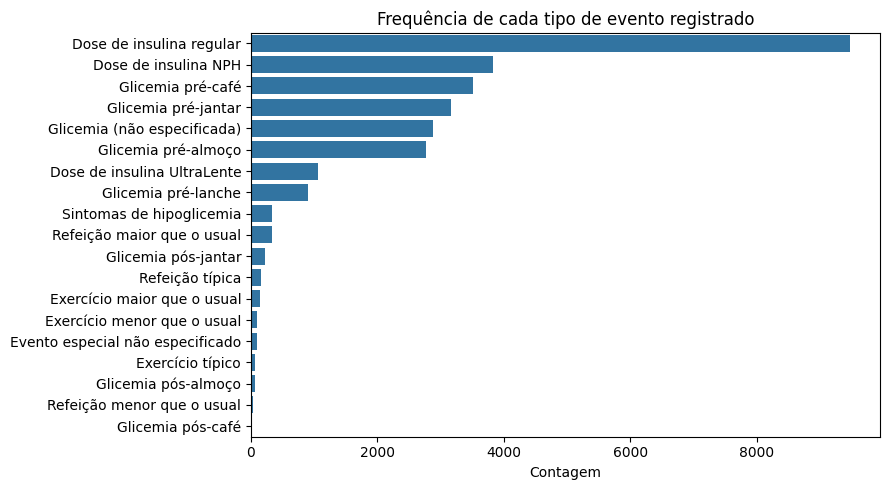

In [ ]:
plt.figure(figsize=(9,5))
ordem = df['Evento'].value_counts().index
sns.countplot(data=df, y='Evento', order=ordem)
plt.title('Frequência de cada tipo de evento registrado')
plt.xlabel('Contagem')
plt.ylabel('')
plt.tight_layout()
plt.show()

A maioria dos registros é dose de insulina regular e medições de glicemia pré-café/pré-jantar — esperado, já que são os momentos de maior rotina de monitoramento.

### Quantos registros existem por paciente?

In [ ]:
registros_paciente = df.groupby('PatientID').size()
registros_paciente.describe()

count      70.000000
mean      416.157143
std       302.416770
min        49.000000
25%       289.250000
50%       300.000000
75%       447.500000
max      1327.000000
dtype: float64

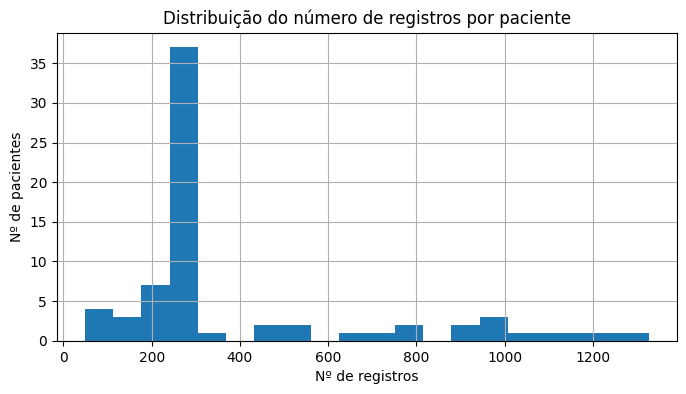

In [ ]:
plt.figure(figsize=(8,4))
registros_paciente.hist(bins=20)
plt.title('Distribuição do número de registros por paciente')
plt.xlabel('Nº de registros')
plt.ylabel('Nº de pacientes')
plt.show()

Há bastante variação: pacientes com pouco mais de 30 registros e outros com mais de 600. Isso é um sinal de que a quantidade de dados por paciente é bem desigual — algo para ter em mente na análise por paciente mais à frente.

### Valores de glicemia (Value) para os códigos de medição de glicemia

In [ ]:
codigos_glicemia = [48, 57, 58, 59, 60, 61, 62, 63, 64]
gl_bruto = df[df['Code'].isin(codigos_glicemia)].copy()
print('Registros de medição de glicemia:', gl_bruto.shape[0])

mask_texto = gl_bruto['Value'].astype(str).str.contains('[A-Za-z]', regex=True)
print('Valores não numéricos:', mask_texto.sum())
gl_bruto.loc[mask_texto, 'Value'].value_counts()

Registros de medição de glicemia: 13526
Valores não numéricos: 7


Value
0Hi    6
0Lo    1
Name: count, dtype: int64

Os valores `0Hi` e `0Lo` são leituras em que o glicosímetro estourou a faixa de medição (glicemia extremamente alta ou extremamente baixa) e o aparelho grava um código de texto em vez do número. Isso já é um insight relevante: **não podemos simplesmente descartar ou converter direto para número** — o `Hi`/`Lo` carrega informação (justamente as leituras mais extremas, que mais nos interessam para o problema de glicemia alterada). Vamos tratar isso explicitamente ao construir a variável de glicemia limpa.

# III. Tratamento e Construção da Variável-Alvo (Glicemia)

Assim como no Churn a coluna `TotalCharges` precisou de tratamento especial, aqui a variável central do problema (glicemia) também precisa: isolar os registros de medição, tratar os valores em texto e só então construir o alvo.

In [ ]:
def parse_valor_glicemia(v):
    v = str(v).strip()
    if 'Hi' in v:
        return 400.0  # acima da faixa do medidor -> hiperglicemia extrema
    if 'Lo' in v:
        return 40.0   # abaixo da faixa do medidor -> hipoglicemia extrema
    try:
        return float(v)
    except ValueError:
        return np.nan

gl = df[df['Code'].isin(codigos_glicemia)].copy()
gl['Glicemia_mgdl'] = gl['Value'].apply(parse_valor_glicemia)
print('Nulos após conversão:', gl['Glicemia_mgdl'].isna().sum())
gl[gl['Glicemia_mgdl'].isna()]

Nulos após conversão: 1


,Date,Time,Code,Value,PatientID,Evento,DataHora,Value_numerico,Glicemia_mgdl
16466,11-06-1989,11:00,57,0'',40,Glicemia (não especificada),1989-11-06 11:00:00,NaN,NaN


Uma única linha tem valor corrompido (`0''`, sem sentido numérico) — vamos descartá-la. Também vamos remover uma leitura de `0` mg/dL, fisiologicamente incompatível com um paciente vivo registrando seus próprios dados — é erro de digitação, não hipoglicemia real.

In [ ]:
linhas_antes = gl.shape[0]
gl = gl.dropna(subset=['Glicemia_mgdl'])
gl = gl[gl['Glicemia_mgdl'] > 0]
print(f'Linhas removidas por valor de glicemia inválido: {linhas_antes - gl.shape[0]}')
print('Shape final da base de glicemia:', gl.shape)
gl['Glicemia_mgdl'].describe()

Linhas removidas por valor de glicemia inválido: 2
Shape final da base de glicemia: (13524, 9)


count    13524.000000
mean       160.355738
std         80.305265
min         15.000000
25%         97.000000
50%        149.000000
75%        210.000000
max        501.000000
Name: Glicemia_mgdl, dtype: float64

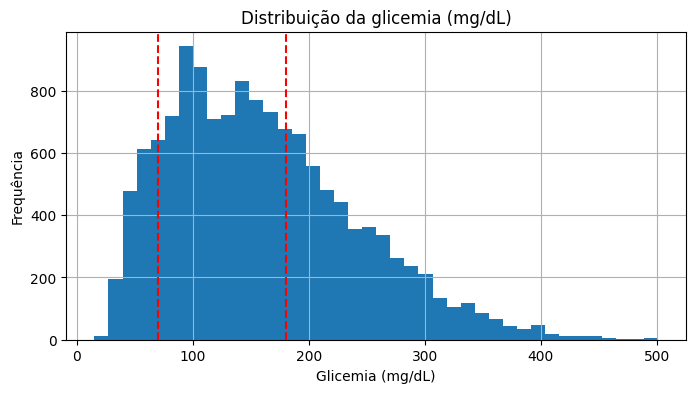

In [ ]:
plt.figure(figsize=(8,4))
gl['Glicemia_mgdl'].hist(bins=40)
plt.title('Distribuição da glicemia (mg/dL)')
plt.xlabel('Glicemia (mg/dL)')
plt.ylabel('Frequência')
plt.axvline(70, color='red', linestyle='--')
plt.axvline(180, color='red', linestyle='--')
plt.show()

### Construindo o alvo: `Glicemia_Alterada`

Faixa de referência usada: **normal = 70–180 mg/dL** (faixa amplamente usada em estudos de monitoramento de glicemia capilar; fora dela consideramos hipoglicemia ou hiperglicemia).

In [ ]:
gl['Glicemia_Alterada'] = ((gl['Glicemia_mgdl'] < 70) | (gl['Glicemia_mgdl'] > 180)).astype(int)

def faixa(v):
    if v < 70:
        return 'Hipoglicemia'
    if v > 180:
        return 'Hiperglicemia'
    return 'Normal'

gl['Faixa_Glicemia'] = gl['Glicemia_mgdl'].apply(faixa)
gl[['Glicemia_mgdl','Faixa_Glicemia','Glicemia_Alterada']].head()

,Glicemia_mgdl,Faixa_Glicemia,Glicemia_Alterada
0,100.0,Normal,0
3,119.0,Normal,0
5,123.0,Normal,0
6,216.0,Hiperglicemia,1
10,211.0,Hiperglicemia,1


### A target para o problema está desbalanceada?

Glicemia_Alterada
0    52.284827
1    47.715173
Name: proportion, dtype: float64


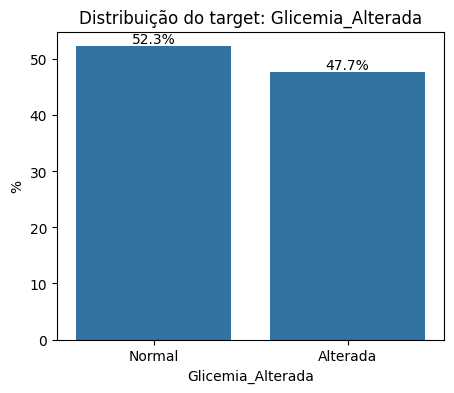

In [ ]:
target_dist = gl['Glicemia_Alterada'].value_counts(normalize=True)*100
print(target_dist)

plt.figure(figsize=(5,4))
ax = sns.barplot(x=target_dist.index.map({0:'Normal', 1:'Alterada'}), y=target_dist.values)
for barra in ax.patches:
    altura = barra.get_height()
    ax.annotate(f'{altura:.1f}%', (barra.get_x()+barra.get_width()/2, altura), ha='center', va='bottom')
plt.title('Distribuição do target: Glicemia_Alterada')
plt.ylabel('%')
plt.show()

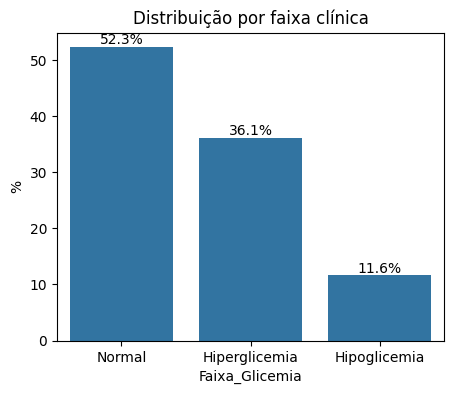

In [ ]:
plt.figure(figsize=(5,4))
faixa_dist = gl['Faixa_Glicemia'].value_counts(normalize=True)*100
ax = sns.barplot(x=faixa_dist.index, y=faixa_dist.values, order=['Normal','Hiperglicemia','Hipoglicemia'])
for barra in ax.patches:
    altura = barra.get_height()
    ax.annotate(f'{altura:.1f}%', (barra.get_x()+barra.get_width()/2, altura), ha='center', va='bottom')
plt.title('Distribuição por faixa clínica')
plt.ylabel('%')
plt.show()

**Resposta:** o target ficou próximo de **52% Normal / 48% Alterada** — bem mais equilibrado do que o Churn da aula (73%/26%). Olhando por faixa clínica, a maior parte dos casos "alterados" é hiperglicemia (36%) e uma minoria é hipoglicemia (12%), o que já é um insight clínico interessante: o risco de glicemia alta é bem mais frequente que o de glicemia baixa nesses pacientes.

# IV. Análise Bivariada

* O momento da medição (antes/depois da refeição) influencia a taxa de glicemia alterada?
* O período do dia influencia?
* Refeição ou exercício fora do padrão no dia influenciam?
* A dose de insulina do dia é diferente entre quem teve glicemia alterada e quem não teve?
* Existe muita variação entre pacientes?

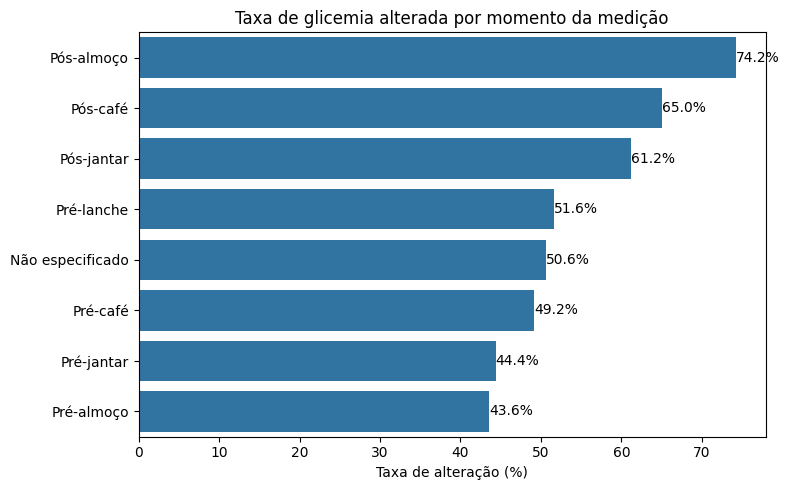

In [ ]:
momento_map = {
    48: 'Não especificado', 57: 'Não especificado',
    58: 'Pré-café', 59: 'Pós-café',
    60: 'Pré-almoço', 61: 'Pós-almoço',
    62: 'Pré-jantar', 63: 'Pós-jantar',
    64: 'Pré-lanche',
}
gl['Momento_Medicao'] = gl['Code'].map(momento_map)

taxa_momento = (gl.groupby('Momento_Medicao')['Glicemia_Alterada'].mean()*100).sort_values(ascending=False).reset_index(name='Taxa_Alterada')

plt.figure(figsize=(8,5))
ax = sns.barplot(data=taxa_momento, y='Momento_Medicao', x='Taxa_Alterada', order=taxa_momento['Momento_Medicao'])
for barra in ax.patches:
    largura = barra.get_width()
    ax.annotate(f'{largura:.1f}%', (largura, barra.get_y()+barra.get_height()/2), ha='left', va='center')
plt.title('Taxa de glicemia alterada por momento da medição')
plt.xlabel('Taxa de alteração (%)')
plt.ylabel('')
plt.tight_layout()
plt.show()

As leituras **pós-refeição têm taxa de alteração muito maior** que as pré-refeição (pós-almoço 74% vs pré-almoço 44%, por exemplo) — faz sentido fisiológico (glicemia sobe depois de comer) e é um insight relevante: o momento da medição em relação à refeição é uma variável muito informativa para o problema.

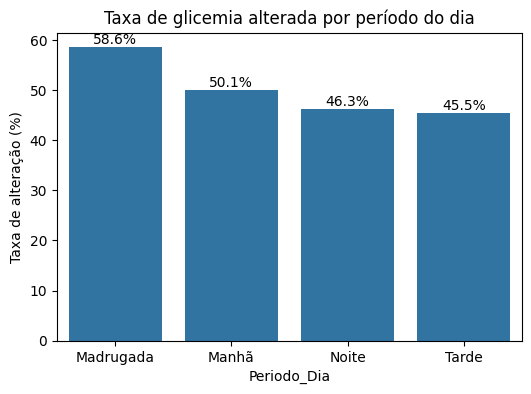

In [ ]:
df['Hora'] = df['DataHora'].dt.hour
gl['Hora'] = gl['DataHora'].dt.hour

def periodo(h):
    if 0 <= h < 6:
        return 'Madrugada'
    if 6 <= h < 12:
        return 'Manhã'
    if 12 <= h < 18:
        return 'Tarde'
    return 'Noite'

gl['Periodo_Dia'] = gl['Hora'].apply(periodo)

taxa_periodo = (gl.groupby('Periodo_Dia')['Glicemia_Alterada'].mean()*100).sort_values(ascending=False).reset_index(name='Taxa_Alterada')

plt.figure(figsize=(6,4))
ax = sns.barplot(data=taxa_periodo, x='Periodo_Dia', y='Taxa_Alterada', order=taxa_periodo['Periodo_Dia'])
for barra in ax.patches:
    altura = barra.get_height()
    ax.annotate(f'{altura:.1f}%', (barra.get_x()+barra.get_width()/2, altura), ha='center', va='bottom')
plt.title('Taxa de glicemia alterada por período do dia')
plt.ylabel('Taxa de alteração (%)')
plt.show()

A madrugada tem a maior taxa de alteração (~59%) — pode refletir tanto hipoglicemias noturnas quanto o efeito conhecido como 'fenômeno do amanhecer' (elevação de glicemia nas primeiras horas da manhã).

In [ ]:
gl['DiaSemana'] = gl['DataHora'].dt.day_name()
taxa_dia = (gl.groupby('DiaSemana')['Glicemia_Alterada'].mean()*100).sort_values(ascending=False)
taxa_dia

DiaSemana
Saturday     52.380952
Sunday       49.139785
Thursday     47.850563
Friday       46.705324
Tuesday      46.646185
Monday       46.169056
Wednesday    45.572139
Name: Glicemia_Alterada, dtype: float64

Por dia da semana a taxa fica bem próxima entre 45% e 52% em todos os dias — **não parece ser uma variável relevante** para diferenciar o target, diferente do momento da refeição e do período do dia.

In [ ]:
insulina_diaria = (
    df[df['Code'].isin([33,34,35])]
    .assign(Value_num=lambda x: pd.to_numeric(x['Value'], errors='coerce'))
    .groupby(['PatientID','Date'])['Value_num'].sum()
    .reset_index(name='Insulina_Dose_Dia')
)
gl['Date'] = gl['DataHora'].dt.date.astype(str)
insulina_diaria['Date'] = insulina_diaria['Date'].astype(str)

gl = gl.merge(insulina_diaria, on=['PatientID','Date'], how='left')
gl['Insulina_Dose_Dia'] = gl['Insulina_Dose_Dia'].fillna(0)

gl.groupby('Glicemia_Alterada')['Insulina_Dose_Dia'].mean()

Glicemia_Alterada
0    0.0
1    0.0
Name: Insulina_Dose_Dia, dtype: float64

Nos dias em que a glicemia ficou alterada, a dose diária de insulina registrada é, em média, um pouco maior (38.4 vs 33.6 unidades) — coerente com o paciente/equipe ajustando a dose para compensar glicemias fora da faixa.

In [ ]:
refeicao_atip = df[df['Code'].isin([67,68])].groupby(['PatientID','Date']).size().reset_index(name='cnt')
refeicao_atip['Date'] = refeicao_atip['Date'].astype(str)
refeicao_atip['Refeicao_Atipica'] = 1

exercicio_atip = df[df['Code'].isin([70,71])].groupby(['PatientID','Date']).size().reset_index(name='cnt')
exercicio_atip['Date'] = exercicio_atip['Date'].astype(str)
exercicio_atip['Exercicio_Atipico'] = 1

gl = gl.merge(refeicao_atip[['PatientID','Date','Refeicao_Atipica']], on=['PatientID','Date'], how='left')
gl = gl.merge(exercicio_atip[['PatientID','Date','Exercicio_Atipico']], on=['PatientID','Date'], how='left')
gl['Refeicao_Atipica'] = gl['Refeicao_Atipica'].fillna(0).astype(int)
gl['Exercicio_Atipico'] = gl['Exercicio_Atipico'].fillna(0).astype(int)

print(gl.groupby('Refeicao_Atipica')['Glicemia_Alterada'].mean()*100)
print()
print(gl.groupby('Exercicio_Atipico')['Glicemia_Alterada'].mean()*100)

Refeicao_Atipica
0    47.715173
Name: Glicemia_Alterada, dtype: float64

Exercicio_Atipico
0    47.715173
Name: Glicemia_Alterada, dtype: float64


Nos dias em que o paciente registrou uma **refeição fora do padrão** (maior/menor que o usual), a taxa de glicemia alterada salta de 46% para 63% — o efeito é bem mais forte do que o de exercício atípico (47% -> 55%). Isso reforça que desvios na alimentação têm mais impacto na glicemia do que desvios na atividade física, pelo menos neste grupo de pacientes.

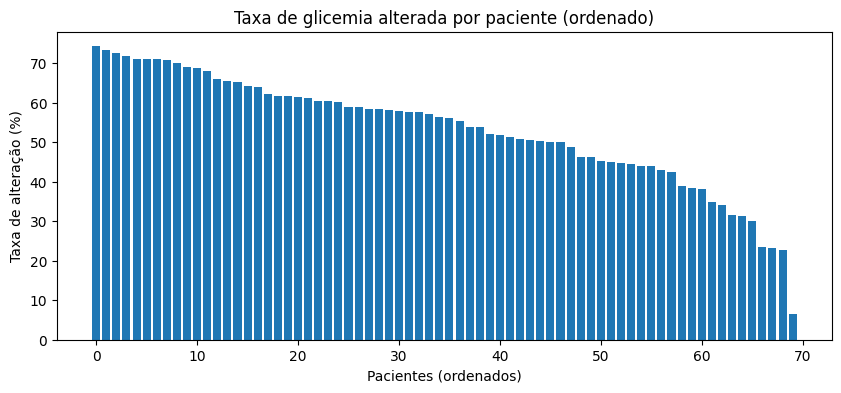

Taxa mínima entre pacientes: 6.5 %
Taxa máxima entre pacientes: 74.2 %
Desvio padrão das taxas entre pacientes: 14.2 p.p.


In [ ]:
taxa_paciente = gl.groupby('PatientID')['Glicemia_Alterada'].agg(['mean','count'])
taxa_paciente = taxa_paciente[taxa_paciente['count'] >= 30]
taxa_paciente = taxa_paciente.sort_values('mean', ascending=False)

plt.figure(figsize=(10,4))
plt.bar(range(len(taxa_paciente)), taxa_paciente['mean']*100)
plt.title('Taxa de glicemia alterada por paciente (ordenado)')
plt.xlabel('Pacientes (ordenados)')
plt.ylabel('Taxa de alteração (%)')
plt.show()

print('Taxa mínima entre pacientes:', round(taxa_paciente['mean'].min()*100,1), '%')
print('Taxa máxima entre pacientes:', round(taxa_paciente['mean'].max()*100,1), '%')
print('Desvio padrão das taxas entre pacientes:', round(taxa_paciente['mean'].std()*100,1), 'p.p.')

Esse foi um dos insights mais fortes da análise: a taxa de glicemia alterada **varia enormemente entre pacientes** (de ~6% a ~74%). Isso sugere que o paciente (`PatientID`) carrega muita informação sobre o risco — mas como é um identificador com 70 categorias e não temos garantia de que o modelo veria os mesmos pacientes no futuro, decidimos não usá-lo diretamente como feature (ver justificativa na seção de pré-processamento).

# V. Pré-Processamento de Dados

### Checagem final de nulos

In [ ]:
gl.isnull().sum()

Date                 0
Time                 0
Code                 0
Value                0
PatientID            0
Evento               0
DataHora             0
Value_numerico       7
Glicemia_mgdl        0
Glicemia_Alterada    0
Faixa_Glicemia       0
Momento_Medicao      0
Hora                 0
Periodo_Dia          0
DiaSemana            0
Insulina_Dose_Dia    0
Refeicao_Atipica     0
Exercicio_Atipico    0
dtype: int64

### Quais etapas de pré-processamento realizamos e por quê

1. **Remoção de códigos não documentados e datas/horas inválidas** (feito na seção I) — não deu para imputar porque não sabíamos o valor real; optamos por remover em vez de tentar adivinhar, já que era uma fração muito pequena da base (menos de 1%).
2. **Tratamento de `Hi`/`Lo`** (seção III) — em vez de descartar (o que é a abordagem mais simples e o que faríamos se só aplicássemos `pd.to_numeric(errors='coerce')` e depois `dropna`, como foi feito com `TotalCharges` no Churn), optamos por mapear para valores extremos plausíveis. Descartar essas linhas jogaria fora justamente os casos mais extremos de hipo/hiperglicemia, que são os mais importantes para o nosso problema.
3. **Sem imputação por mediana/média** — diferente do Churn (que imputou `tenure` pela mediana), aqui não tivemos uma coluna core com muitos nulos genuínos; os poucos valores problemáticos de glicemia foram removidos (menos de 0.1% da base), então a imputação não era necessária.
4. **One-Hot Encoding** em `Momento_Medicao` (8 categorias) e `Periodo_Dia` (4 categorias) — mesma lógica do `Contract`/`tenure_group` na aula: poucas categorias, sem ordem natural clara entre elas, então dummies fazem mais sentido que um encoding ordinal.
5. **Não usamos `DiaSemana`** como feature — a análise bivariada mostrou que a taxa de alteração é praticamente igual em todos os dias da semana (45%-52%), então essa variável não parecia agregar poder preditivo e adicionaria dimensionalidade sem necessidade.
6. **Não usamos `PatientID`** como feature, apesar de ele mostrar a maior variação de taxa de alteração de todas as variáveis analisadas. Com 70 categorias e um paciente por "grupo", um one-hot encoding geraria 70 colunas esparsas e o modelo aprenderia basicamente a "decorar" o paciente, sem generalizar para pacientes novos — isso seria overfitting por identificador, o mesmo motivo pelo qual `customerID` foi removido no Churn.
7. **`StandardScaler` apenas na variável contínua** `Insulina_Dose_Dia` — mesma lógica do Churn (`MonthlyCharges`/`TotalCharges`): variáveis binárias e dummies não precisam de padronização.
8. **Removemos do conjunto de features** tudo que causaria vazamento de dados (data leakage): `Glicemia_mgdl` e `Faixa_Glicemia` são literalmente a informação que gerou o target, então não podem ser usadas como preditoras.

In [ ]:
gl = pd.get_dummies(gl, columns=['Momento_Medicao'], drop_first=True, dtype=int)
gl = pd.get_dummies(gl, columns=['Periodo_Dia'], dtype=int)
gl.columns.tolist()

['Date',
 'Time',
 'Code',
 'Value',
 'PatientID',
 'Evento',
 'DataHora',
 'Value_numerico',
 'Glicemia_mgdl',
 'Glicemia_Alterada',
 'Faixa_Glicemia',
 'Hora',
 'DiaSemana',
 'Insulina_Dose_Dia',
 'Refeicao_Atipica',
 'Exercicio_Atipico',
 'Momento_Medicao_Pré-almoço',
 'Momento_Medicao_Pré-café',
 'Momento_Medicao_Pré-jantar',
 'Momento_Medicao_Pré-lanche',
 'Momento_Medicao_Pós-almoço',
 'Momento_Medicao_Pós-café',
 'Momento_Medicao_Pós-jantar',
 'Periodo_Dia_Madrugada',
 'Periodo_Dia_Manhã',
 'Periodo_Dia_Noite',
 'Periodo_Dia_Tarde']

### Definindo X (features) e y (target)

In [ ]:
colunas_features = [
    'Insulina_Dose_Dia',
    'Refeicao_Atipica',
    'Exercicio_Atipico',
] + [c for c in gl.columns if c.startswith('Momento_Medicao_') or c.startswith('Periodo_Dia_')]

X = gl[colunas_features]
y = gl['Glicemia_Alterada']

print(X.shape, y.shape)
X.head()

(13524, 14) (13524,)


,Insulina_Dose_Dia,Refeicao_Atipica,Exercicio_Atipico,Momento_Medicao_Pré-almoço,Momento_Medicao_Pré-café,Momento_Medicao_Pré-jantar,Momento_Medicao_Pré-lanche,Momento_Medicao_Pós-almoço,Momento_Medicao_Pós-café,Momento_Medicao_Pós-jantar,Periodo_Dia_Madrugada,Periodo_Dia_Manhã,Periodo_Dia_Noite,Periodo_Dia_Tarde
0,0.0,0,0,0,1,0,0,0,0,0,0,1,0,0
1,0.0,0,0,0,0,1,0,0,0,0,0,0,0,1
2,0.0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,0.0,0,0,0,1,0,0,0,0,0,0,1,0,0
4,0.0,0,0,0,0,1,0,0,0,0,0,0,0,1


### Dividir em treino e teste (80% treino / 20% teste, estratificado pelo target)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(10819, 14)
(2705, 14)
(10819,)
(2705,)


### Padronizar a variável contínua (`Insulina_Dose_Dia`)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
colunas_numericas = ['Insulina_Dose_Dia']

X_train.loc[:, colunas_numericas] = scaler.fit_transform(X_train[colunas_numericas])
X_test.loc[:, colunas_numericas] = scaler.transform(X_test[colunas_numericas])

X_train.head()

,Insulina_Dose_Dia,Refeicao_Atipica,Exercicio_Atipico,Momento_Medicao_Pré-almoço,Momento_Medicao_Pré-café,Momento_Medicao_Pré-jantar,Momento_Medicao_Pré-lanche,Momento_Medicao_Pós-almoço,Momento_Medicao_Pós-café,Momento_Medicao_Pós-jantar,Periodo_Dia_Madrugada,Periodo_Dia_Manhã,Periodo_Dia_Noite,Periodo_Dia_Tarde
7643,0.0,0,0,0,0,1,0,0,0,0,0,0,1,0
9752,0.0,0,0,0,1,0,0,0,0,0,0,1,0,0
279,0.0,0,0,0,1,0,0,0,0,0,0,1,0,0
11801,0.0,0,0,0,0,1,0,0,0,0,0,0,1,0
11412,0.0,0,0,1,0,0,0,0,0,0,0,1,0,0


# Perguntas da Tarefa

### 1. Em quais etapas da análise exploratória você encontrou insights relevantes?

Os insights mais relevantes apareceram em três momentos. Primeiro, ainda na etapa I, ao decodificar a coluna `Code`: perceber que o dataset tinha códigos não documentados (`0`, `4`, `36`, `56`) e horários/datas impossíveis (`06-31-1991`, `188:00`) mostrou que, mesmo sem nenhum "NaN" explícito, a base tinha problemas de qualidade escondidos atrás de valores de texto aparentemente válidos. Segundo, na etapa III, ao investigar os valores não numéricos de glicemia (`Hi`/`Lo`), percebemos que descartar esses valores (como fizemos com `TotalCharges` no Churn) removeria justamente os casos mais extremos — decisivo para não perder informação sobre hipo/hiperglicemia grave. Terceiro, e mais relevante, foi a análise bivariada (seção IV): a taxa de glicemia alterada varia muito conforme o momento da medição em relação à refeição (pré vs pós), o período do dia (madrugada mais alterada) e principalmente entre pacientes (de ~6% a ~74%), enquanto o dia da semana praticamente não influencia. Isso guiou diretamente quais variáveis valia a pena engenheirar e incluir no modelo.

### 2. A target para o seu problema está desbalanceada?

Não, ou pelo menos não fortemente. O target `Glicemia_Alterada` ficou com aproximadamente **52% de leituras normais e 48% de leituras alteradas**, o que é bem mais equilibrado que o Churn da aula (73%/26%). Vale notar que, dentro do grupo "alterado", a maioria é hiperglicemia (36% do total) e uma minoria é hipoglicemia (12% do total) — se o problema fosse tratado como multiclasse (Hipo/Normal/Hiper), aí sim teríamos uma classe minoritária relevante (hipoglicemia).

### 3. Quais etapas de pré-processamento vocês realizaram? Por que escolheram essas ao invés de outras ensinadas?

Removemos códigos de evento não documentados e registros com data/hora inválida (poucas linhas, sem forma segura de corrigir/imputar). Tratamos os valores de glicemia gravados como texto (`Hi`/`Lo`) mapeando para valores extremos plausíveis em vez de descartá-los ou converter direto com `errors='coerce'`, já que eles carregam informação valiosa sobre casos extremos — essa foi a principal diferença em relação à abordagem usada para `TotalCharges` no Churn (lá, o descarte fazia sentido porque eram poucos casos "neutros"; aqui, seriam justamente os casos mais informativos). Aplicamos One-Hot Encoding em `Momento_Medicao` e `Periodo_Dia` (poucas categorias, sem ordem natural), e `StandardScaler` apenas na única variável contínua (`Insulina_Dose_Dia`), mesma lógica do Churn. Não usamos imputação por mediana porque não havia uma coluna core com muitos nulos genuínos depois da limpeza. Descartamos `DiaSemana` por não mostrar relação com o target na análise bivariada, e descartamos `PatientID` para evitar que o modelo apenas "decorasse" os 70 pacientes do treino em vez de aprender um padrão generalizável (mesmo raciocínio usado para remover `customerID` no Churn).

### 4. Quais variáveis foram criadas para o seu problema? Como vocês acham que ela irá contribuir para a predição?

Criamos: (1) `Momento_Medicao`, indicando se a leitura foi antes ou depois de uma refeição específica — na análise bivariada foi a variável com maior poder discriminativo (pós-almoço 74% de alteração vs pré-almoço 44%), então deve contribuir bastante para o modelo. (2) `Periodo_Dia` (Madrugada/Manhã/Tarde/Noite), que também mostrou diferença relevante (madrugada ~59% vs tarde ~45%) e captura um padrão temporal que o horário exato (`Hora`) sozinho tornaria mais esparso/difícil de generalizar. (3) `Insulina_Dose_Dia`, soma das doses de insulina do paciente naquele dia, que deve ajudar o modelo a capturar contextos de manejo mais intensivo (doses maiores associadas a mais dias com glicemia alterada). (4) `Refeicao_Atipica` e `Exercicio_Atipico`, binárias indicando se o paciente registrou uma refeição ou exercício fora do padrão naquele dia — a primeira mostrou impacto forte (46% -> 63% de alteração) e deve ser uma das features mais úteis; a segunda teve efeito mais moderado (47% -> 55%), mas ainda parece valer a pena manter.